## Setup

In [23]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

REPORTS_DIR = Path.cwd() / "reports"

In [24]:
palette = [
    "#0072B2",
    "#6EC6F0",
    "#1A3A6B",
    "#77D4CC",
    "#009E73",
    "#44AA99",
    "#F2E55C",
    "#E69F00",
    "#556B00",
    "#D4669A",
    "#CC3311",
    "#DDDDDD",
    "#222222",
    "#882255"
]

cmap = mcolors.ListedColormap(palette, name="custom")

## Load Reports

In [25]:
def load_reports(report_dir):
    reports = {}
    for p in report_dir.glob("*_build_status.json"):
        repo = p.stem.replace("_build_status", "")
        with p.open() as f: raw = json.load(f)
        reports[repo] = raw["report"]
    return reports

reports = load_reports(REPORTS_DIR)
print("repos:", len(reports))

repos: 10


## Convert to DataFrames

In [26]:
def flatten_totals(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "totals" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for section, metrics in report["totals"].items():
            section_label = section_labels[section]
            for metric, value in metrics.items():
                metric_label = field_labels[metric]
                rows.append({
                    "repo": repo,
                    "section": section_label,
                    "metric": metric_label,
                    "value": value
                })
        section_timing = "Timing"
        report = row if "timing" in row else row["report"]
        phase_labels = report["labels"]["phases"]
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_total_seconds"],
            "value": report["timing"]["build_total_seconds"]
        })
        rows.append({
            "repo": repo,
            "section": section_timing,
            "metric": field_labels["build_wall_seconds"],
            "value": report["timing"]["build_wall_seconds"]
        })
        for phase, time in report["timing"]["build_phase_timings"].items():
            rows.append({
                "repo": repo,
                "section": section_timing,
                "metric": phase_labels[phase],
                "value": time
            })

    return pd.DataFrame(rows)

totals_df= flatten_totals(reports)

In [27]:
def flatten_scopes(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "scopes" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        scope_labels = report["labels"]["scopes"]
        for scope, sections in report["scopes"].items():
            scope_label = scope_labels[scope]
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "scope": scope_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

scopes_df= flatten_scopes(reports)

In [28]:
def flatten_languages(reports):
    rows = []
    for repo, row in reports.items():
        report = row if "languages" in row else row["report"]
        section_labels = report["labels"]["sections"]
        field_labels = report["labels"]["fields"]
        for language, sections in report["languages"].items():
            language_label = language
            for section, metrics in sections.items():
                section_label = section_labels[section]
                for metric, value in metrics.items():
                    metric_label = field_labels[metric]
                    rows.append({
                        "repo": repo,
                        "language": language_label,
                        "section": section_label,
                        "metric": metric_label,
                        "value": value
                    })

    return pd.DataFrame(rows)

languages_df= flatten_languages(reports)

## Service functions

In [29]:
def df_section(df, section):
    subset = df[df.section == section]
    return subset.pivot(index="repo", columns="metric", values="value")

## Overview

In [30]:
totals_pivot = totals_df.pivot(
    index="repo",
    columns=["section","metric"],
    values="value")

totals_pivot

section      Call Materialization                                 Callsites  \
metric             Callsite Pairs Finalized Call Edges Filtered Pre-Persist   
repo                                                                          
airbyte                   14988.0              14148.0                346.0   
commons-lang               5718.0               5713.0                205.0   
eslint                      649.0                648.0                 37.0   
guava                     36099.0              36064.0               1266.0   
npm-cli                    5140.0               5135.0                232.0   
pydantic                   2717.0               2708.0                397.0   
rollup                     8362.0               8320.0               3685.0   
sympy                     61673.0              61122.0              11047.0   
vscode                   184079.0             182390.0               3046.0   
webpack                    3189.0               3183.0                156.0   

section                                                       \
metric       Observed Syntactic Callsites Persisted Accepted   
repo                                                           
airbyte                           15626.0            14976.0   
commons-lang                       5692.0             5376.0   
eslint                              689.0              649.0   
guava                             36639.0            34844.0   
npm-cli                            5445.0             5140.0   
pydantic                           3263.0             2717.0   
rollup                            11852.0             8123.0   
sympy                             72663.0            60213.0   
vscode                           155451.0           148684.0   
webpack                            3368.0             3189.0   

section                                                  Pre-Persist Filter  \
metric       Persisted Callsites Persisted Dropped Accepted Outside In-Repo   
repo                                                                          
airbyte                  15280.0             304.0                      0.0   
commons-lang              5487.0             111.0                      0.0   
eslint                     652.0               3.0                      0.0   
guava                    35373.0             529.0                      0.0   
npm-cli                   5213.0              73.0                      0.0   
pydantic                  2866.0             149.0                      0.0   
rollup                    8167.0              44.0                      0.0   
sympy                    61616.0            1403.0                      0.0   
vscode                  152405.0            3721.0                      0.0   
webpack                   3212.0              23.0                      0.0   

section                                                                     \
metric       Invalid Observation Shape Likely Dynamic Dispatch Or Indirect   
repo                                                                         
airbyte                            0.0                                 0.0   
commons-lang                       0.0                                 0.0   
eslint                             0.0                                 1.0   
guava                              0.0                                 0.0   
npm-cli                            0.0                                 2.0   
pydantic                           0.0                                 0.0   
rollup                             0.0                                39.0   
sympy                              0.0                                 0.0   
vscode                             0.0                               104.0   
webpack                            0.0                                 0.0   

section       ...                    Timing                            \
metric        ... Compu

In [31]:
timing_total_df = df_section(totals_df, "Timing")[["Build Wall Time"]]
timing_total_df = timing_total_df.sort_values("Build Wall Time", ascending=True)
timing_total_df = timing_total_df.join(df_section(totals_df, "Structure")[["Nodes", "Edges"]])
timing_total_df["Nodes + Edges"] = timing_total_df["Nodes"] + timing_total_df["Edges"]
timing_total_df["Time per 1K Nodes"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes"] / 1000)
timing_total_df["Time per 1K Edges"] = timing_total_df["Build Wall Time"] / (timing_total_df["Edges"] / 1000)
timing_total_df["Time per 1K (Nodes + Edges)"] = timing_total_df["Build Wall Time"] / (timing_total_df["Nodes + Edges"] / 1000)

timing_mean = timing_total_df.mean(numeric_only=True)
timing_median = timing_total_df.median(numeric_only=True)
timing_std = timing_total_df.std(numeric_only=True)

timing_mean.name = "Mean"
timing_median.name = "Median"
timing_std.name = "Std"

timing_overview_df = pd.concat([timing_total_df, timing_mean.to_frame().T, timing_std.to_frame().T, timing_median.to_frame().T]).round(2)
timing_overview_df

metric,Build Wall Time,Nodes,Edges,Nodes + Edges,Time per 1K Nodes,Time per 1K Edges,Time per 1K (Nodes + Edges)
pydantic,19.39,13301.00,16727.00,30028.00,1.46,1.16,0.65
eslint,20.80,2905.00,2856.00,5761.00,7.16,7.28,3.61
commons-lang,22.75,11566.00,17316.00,28882.00,1.97,1.31,0.79
npm-cli,34.00,9167.00,14299.00,23466.00,3.71,2.38,1.45
webpack,53.19,14945.00,14436.00,29381.00,3.56,3.68,1.81
rollup,69.45,19557.00,20381.00,39938.00,3.55,3.41,1.74
airbyte,69.52,25275.00,38598.00,63873.00,2.75,1.80,1.09
guava,123.28,64131.00,103276.00,167407.00,1.92,1.19,0.74
sympy,221.50,40980.00,113755.00,154735.00,5.41,1.95,1.43
vscode,920.28,108097.00,353864.00,461961.00,8.51,2.60,1.99


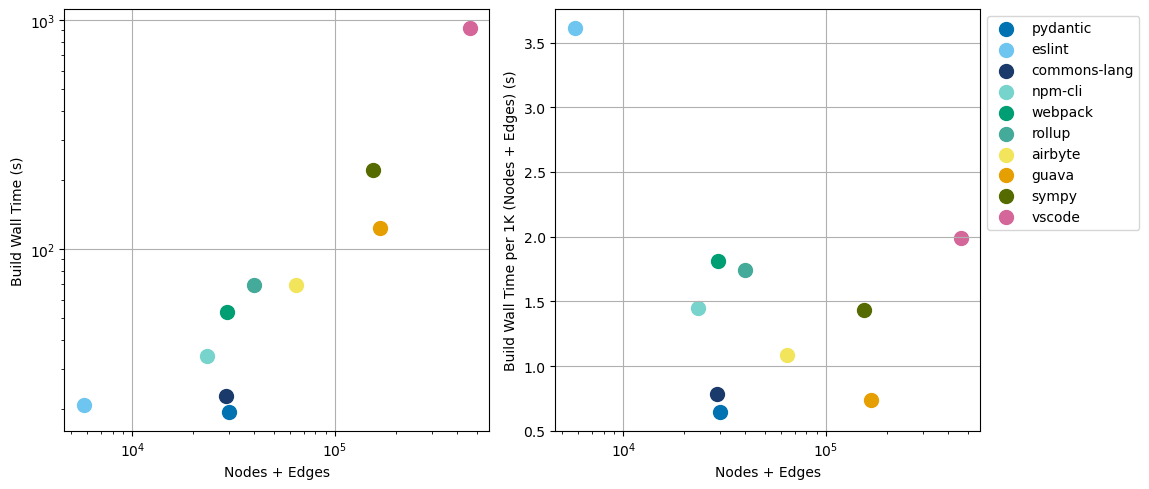

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

for i, repo in enumerate(timing_total_df.index):
    color = palette[i % len(palette)]
    x = timing_total_df.loc[repo, "Nodes + Edges"]
    y1 = timing_total_df.loc[repo, "Build Wall Time"]
    y2 = timing_total_df.loc[repo, "Time per 1K (Nodes + Edges)"]

    axes[0].scatter(x, y1, color=color, s=100, label=repo)
    axes[1].scatter(x, y2, color=color, s=100)

axes[0].set_xlabel("Nodes + Edges")
axes[0].set_ylabel("Build Wall Time (s)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True)

axes[1].set_xlabel("Nodes + Edges")
axes[1].set_ylabel("Build Wall Time per 1K (Nodes + Edges) (s)")
axes[1].set_xscale("log")
axes[1].grid(True)

fig.legend(loc="upper left", bbox_to_anchor=(0.985, 0.97))
plt.tight_layout()
plt.show()

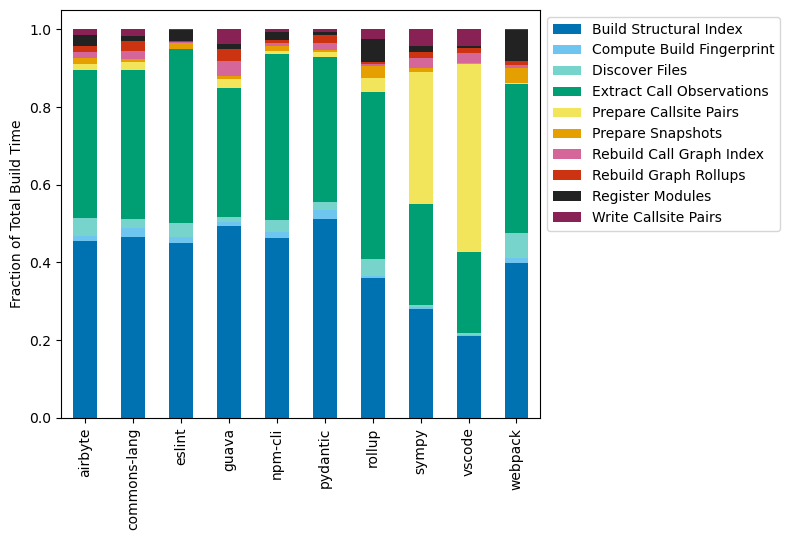

In [33]:
timing_phases_df = df_section(totals_df, "Timing").drop(columns=["Build Total Time", "Build Wall Time", "Diagnostic Classification"], errors="ignore")
timing_phases_df = timing_phases_df.div(timing_phases_df.sum(axis=1), axis=0)

timing_phases_df.plot( kind="bar", stacked=True, colormap=cmap, figsize=(8, 5.5))
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of Total Build Time")
plt.tight_layout()
plt.show()

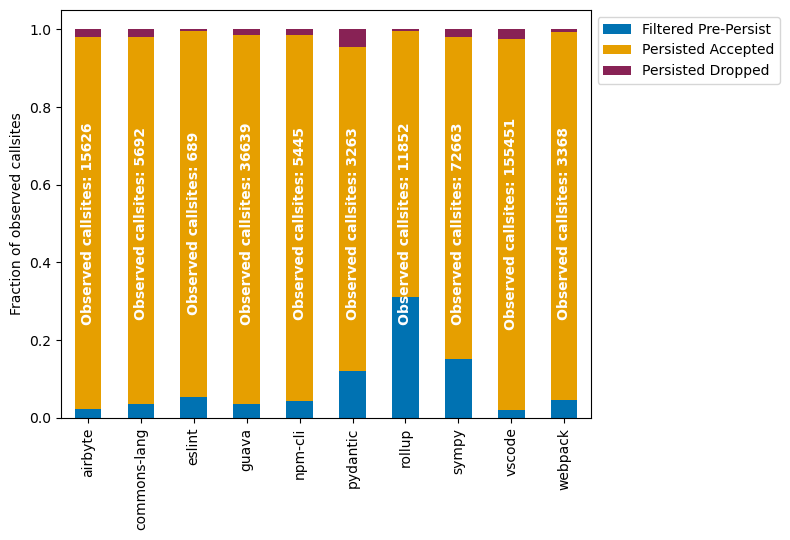

In [34]:
observed_callsites = df_section(totals_df, "Callsites")["Observed Syntactic Callsites"]

callsites_df = df_section(totals_df, "Callsites").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8,5.5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(observed_callsites.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()

In [35]:
callsites_df

metric,Filtered Pre-Persist,Persisted Accepted,Persisted Dropped
repo,,,
airbyte,0.022143,0.958403,0.019455
commons-lang,0.036015,0.944483,0.019501
eslint,0.053701,0.941945,0.004354
guava,0.034553,0.951008,0.014438
npm-cli,0.042608,0.943985,0.013407
pydantic,0.121667,0.832669,0.045663
rollup,0.310918,0.685370,0.003712
sympy,0.152031,0.828661,0.019308
vscode,0.019595,0.956469,0.023937


## Language breakdown

In [36]:
languages_pivot = languages_df.pivot(
    index=["repo","language"],
    columns=["section","metric"],
    values="value")
languages_pivot

section                 Call Materialization                       \
metric                        Callsite Pairs Finalized Call Edges   
repo         language                                               
airbyte      java                       1568                 1568   
             javascript                   53                   53   
             python                    13365                12525   
             typescript                    2                    2   
commons-lang java                       5718                 5713   
eslint       javascript                  649                  648   
             typescript                    0                    0   
guava        java                      36099                36064   
             javascript                    0                    0   
npm-cli      javascript                 3770                 3765   
             python                     1370                 1370   
pydantic     javascript                    8                    8   
             python                     2709                 2700   
rollup       javascript                 5984                 5984   
             typescript                 2378                 2336   
sympy        python                    61673                61122   
vscode       java                          0                    0   
             javascript                  124                  124   
             python                        0                    0   
             typescript               183955               182266   
webpack      javascript                 3177                 3171   
             typescript                   12                   12   

section                            Callsites                               \
metric                  Filtered Pre-Persist Observed Syntactic Callsites   
repo         language                                                       
airbyte      java                         54                         1623   
             javascript                    0                           53   
             python                      292                        13948   
             typescript                    0                            2   
commons-lang java                        205                         5692   
eslint       javascript                   37                          689   
             typescript                    0                            0   
guava        java                       1266                        36639   
             javascript                    0                            0   
npm-cli      javascript                  222                         4050   
             python                       10                         1395   
pydantic     javascript                    0                            8   
             python                      397                         3255   
rollup       javascript                 3506                         9493   
             typescript                  179                         2359   
sympy        python                    11047                        72663   
vscode       java                          0                            0   
             javascript                    1                          125   
             python                        0                            0   
             typescript                 3045                       155326   
webpack      javascript                  156                         3356   
             typescript                    0                           12   

section                                                         \
metric                  Persisted Accepted Persisted Callsites   
repo         language                                            
airbyte      java                     1556                1569   
             javascript                 53                  53   
             pytho

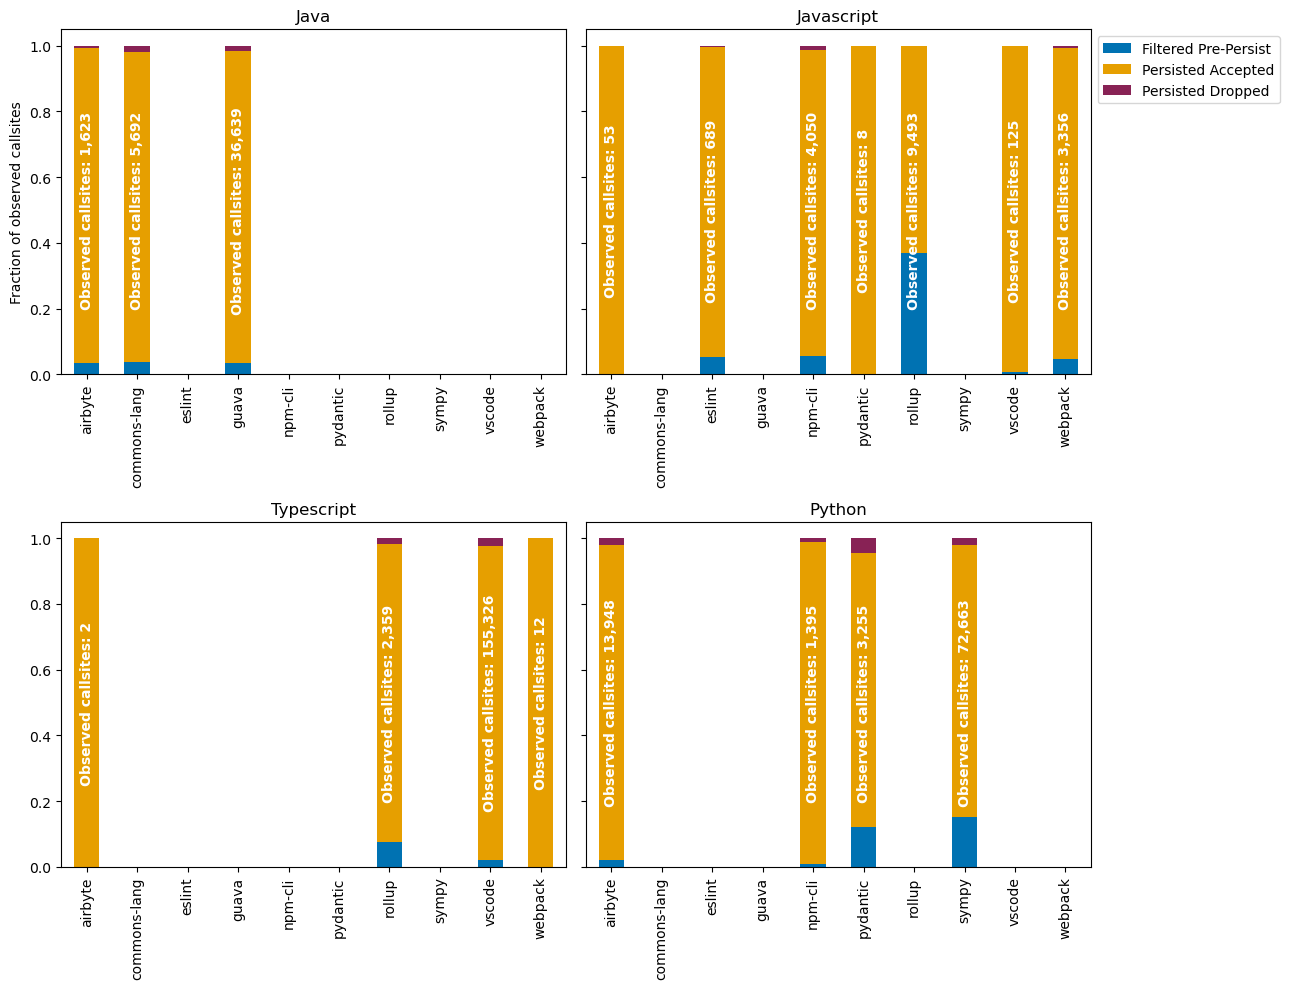

In [37]:
observed_callsites = languages_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

all_repos = callsites_df.index.get_level_values("repo").unique()

java_df = callsites_df.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_df = callsites_df.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_df = callsites_df.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_df = callsites_df.xs("python", level="language").reindex(all_repos, fill_value=0)

java_callsites = observed_callsites.xs("java", level="language").reindex(all_repos, fill_value=0)
javascript_callsites = observed_callsites.xs("javascript", level="language").reindex(all_repos, fill_value=0)
typescript_callsites = observed_callsites.xs("typescript", level="language").reindex(all_repos, fill_value=0)
python_callsites = observed_callsites.xs("python", level="language").reindex(all_repos, fill_value=0)

fig, axes = plt.subplots(2,2, figsize=(13,10), sharey=True)

java_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,0], legend=False)
javascript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0,1])
typescript_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,0], legend=False)
python_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1,1], legend=False)

for i, (repo, value) in enumerate(java_callsites.items()):
    axes[0,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(javascript_callsites.items()):
    axes[0,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(typescript_callsites.items()):
    axes[1,0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(python_callsites.items()):
    axes[1,1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

axes[0,0].set_title("Java")
axes[0,1].set_title("Javascript")
axes[1,0].set_title("Typescript")
axes[1,1].set_title("Python")

for ax in axes.flat: ax.set_xlabel("")
axes[0,0].set_ylabel("Fraction of observed callsites")
axes[0,1].legend(bbox_to_anchor=(1,1), loc="upper left")

plt.tight_layout()
plt.show()

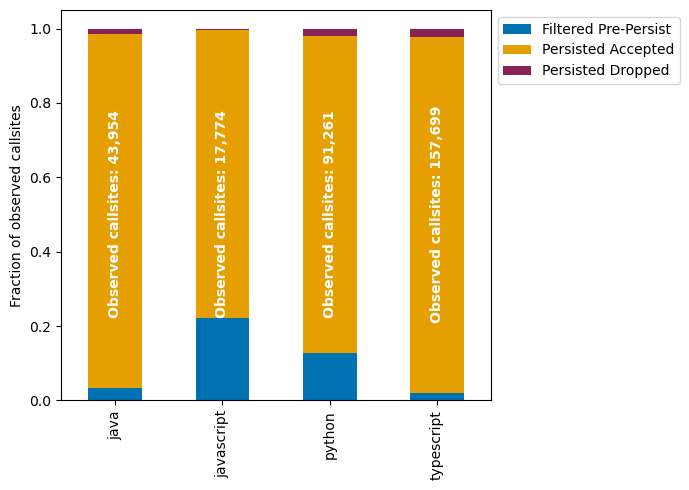

In [38]:
callsites_raw_df = languages_pivot.groupby(level="language").sum()
callsites_counts = callsites_raw_df.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]

callsites_df = languages_pivot.groupby(level="language").sum()
callsites_df = callsites_df.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5))

callsites_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (lang, value) in enumerate(callsites_counts.items()):
    ax.text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

ax.legend(bbox_to_anchor=(1,1), loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Fraction of observed callsites")

plt.tight_layout()
plt.show()

In [39]:
callsites_raw_df

section    Call Materialization                                 Callsites  \
metric           Callsite Pairs Finalized Call Edges Filtered Pre-Persist   
language                                                                    
java                      43385                43345                 1525   
javascript                13765                13753                 3922   
python                    79117                77717                11746   
typescript               186347               184616                 3224   

section                                                     \
metric     Observed Syntactic Callsites Persisted Accepted   
language                                                     
java                              43954              41776   
javascript                        17774              13765   
python                            91261              77657   
typescript                       157699             150713   

section                                                Pre-Persist Filter  \
metric     Persisted Callsites Persisted Dropped Accepted Outside In-Repo   
language                                                                    
java                     42429               653                        0   
javascript               13852                87                        0   
python                   79515              1858                        0   
typescript              154475              3762                        0   

section                                                                   \
metric     Invalid Observation Shape Likely Dynamic Dispatch Or Indirect   
language                                                                   
java                               0                                   0   
javascript                         0                                   4   
python                             0                                   0   
typescript                         0                                 142   

section                                                             \
metric     Likely External Dependency Likely Parser Extraction Gap   
language                                                             
java                                0                         1479   
javascript                          0                           35   
python                              0                           64   
typescript                          0                          111   

section                                                                \
metric     Likely Standard Library Or Builtin Likely Unindexed Symbol   
language                                                                
java                                        0                      46   
javascript                                  0                    3883   
python                                      0                   11682   
typescript                                  0                    2971   

section                                      Structure                 
metric     Unclassified No In-Repo Candidate     Edges  Files   Nodes  
language                                                               
java                                       0    125993   4251   79844  
javascript                                 0     43140  23851   42985  
python                                     0    166312   4820   76701  
typescript                                 0    360063   7128  110394

In [40]:
callsites_df

metric,Filtered Pre-Persist,Persisted Accepted,Persisted Dropped
language,,,
java,0.034695,0.950448,0.014856
javascript,0.220659,0.774446,0.004895
python,0.128708,0.850933,0.020359
typescript,0.020444,0.955700,0.023856


## Scope breakdown

In [41]:
scopes_pivot = scopes_df.pivot(
    index=["repo","scope"],
    columns=["section","metric"],
    values="value")
scopes_pivot

section                Call Materialization                       \
metric                       Callsite Pairs Finalized Call Edges   
repo         scope                                                 
airbyte      Non-Tests                14383                13543   
             Tests                      605                  605   
commons-lang Non-Tests                 3667                 3662   
             Tests                     2051                 2051   
eslint       Non-Tests                  634                  633   
             Tests                       15                   15   
guava        Non-Tests                24194                24159   
             Tests                    11905                11905   
npm-cli      Non-Tests                 5006                 5001   
             Tests                      134                  134   
pydantic     Non-Tests                 1594                 1594   
             Tests                     1123                 1114   
rollup       Non-Tests                 2416                 2374   
             Tests                     5946                 5946   
sympy        Non-Tests                25205                25148   
             Tests                    36468                35974   
vscode       Non-Tests               159725               158049   
             Tests                    24354                24341   
webpack      Non-Tests                 2799                 2793   
             Tests                      390                  390   

section                           Callsites                               \
metric                 Filtered Pre-Persist Observed Syntactic Callsites   
repo         scope                                                         
airbyte      Non-Tests                  341                        15012   
             Tests                        5                          614   
commons-lang Non-Tests                    7                         3403   
             Tests                      198                         2289   
eslint       Non-Tests                   33                          670   
             Tests                        4                           19   
guava        Non-Tests                  177                        23556   
             Tests                     1089                        13083   
npm-cli      Non-Tests                  232                         5311   
             Tests                        0                          134   
pydantic     Non-Tests                  205                         1837   
             Tests                      192                         1426   
rollup       Non-Tests                  186                         2404   
             Tests                     3499                         9448   
sympy        Non-Tests                 2775                        27951   
             Tests                     8272                        44712   
vscode       Non-Tests                 2933                       132767   
             Tests                      113                        22684   
webpack      Non-Tests                  151                         2973   
             Tests                        5                          395   

section                                                        \
metric                 Persisted Accepted Persisted Callsites   
repo         scope                                              
airbyte      Non-Tests              14371               14671   
             Tests                    605                 609   
commons-lang Non-Tests               3325                3396   
             Tests                   2051                2091   
eslint       Non-Tests                634                 637   
             Tests                     15                  15   
guava        Non-Tests              22939               23379   
             Tests                  

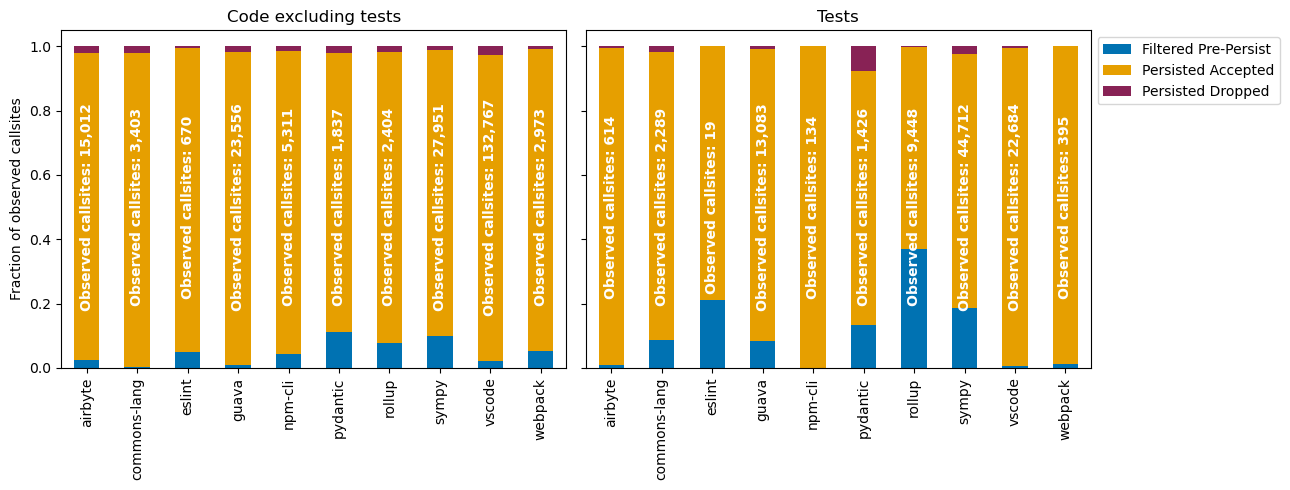

In [42]:
callsites_counts = scopes_pivot.xs("Callsites", axis=1, level="section")["Observed Syntactic Callsites"]
counts_non_tests = callsites_counts.xs("Non-Tests", level="scope")
counts_tests = callsites_counts.xs("Tests", level="scope")

callsites_df = scopes_pivot.xs("Callsites", axis=1, level="section").drop(columns=["Observed Syntactic Callsites", "Persisted Callsites"])
callsites_df = callsites_df.div(callsites_df.sum(axis=1), axis=0)
callsites_df = callsites_df.sort_index(level="repo")

non_test_df = callsites_df.xs("Non-Tests", level="scope")
tests_df = callsites_df.xs("Tests", level="scope")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

non_test_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[0],legend=False)
tests_df.plot(kind="bar", stacked=True, colormap=cmap, ax=axes[1])

for i, (repo, value) in enumerate(counts_non_tests.items()):
    axes[0].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

for i, (repo, value) in enumerate(counts_tests.items()):
    axes[1].text(i, 0.5, f"Observed callsites: {int(value):,}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    
axes[0].set_title("Code excluding tests")
axes[1].set_title("Tests")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of observed callsites")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(bbox_to_anchor=(1,1),loc="upper left")
plt.tight_layout()
plt.show()

## Diagnostics

In [43]:
df_section(totals_df, "Pre-Persist Filter")

metric,Accepted Outside In-Repo,Invalid Observation Shape,Likely Dynamic Dispatch Or Indirect,Likely External Dependency,Likely Parser Extraction Gap,Likely Standard Library Or Builtin,Likely Unindexed Symbol,Unclassified No In-Repo Candidate
repo,,,,,,,,
airbyte,0.0,0.0,0.0,0.0,91.0,0.0,255.0,0.0
commons-lang,0.0,0.0,0.0,0.0,185.0,0.0,20.0,0.0
eslint,0.0,0.0,1.0,0.0,3.0,0.0,33.0,0.0
guava,0.0,0.0,0.0,0.0,1256.0,0.0,10.0,0.0
npm-cli,0.0,0.0,2.0,0.0,0.0,0.0,230.0,0.0
pydantic,0.0,0.0,0.0,0.0,0.0,0.0,397.0,0.0
rollup,0.0,0.0,39.0,0.0,6.0,0.0,3640.0,0.0
sympy,0.0,0.0,0.0,0.0,11.0,0.0,11036.0,0.0
vscode,0.0,0.0,104.0,0.0,105.0,0.0,2837.0,0.0


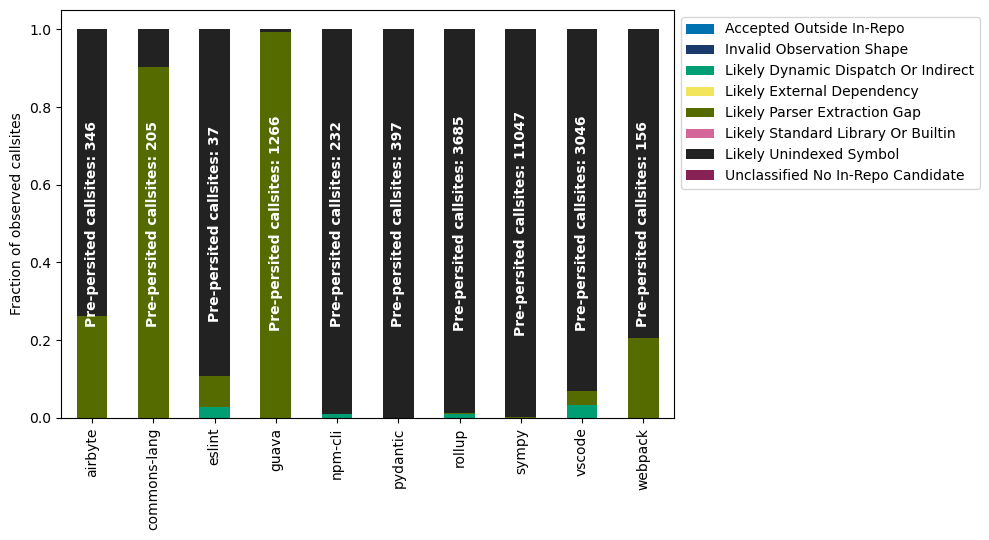

In [44]:
pre_persist = df_section(totals_df, "Callsites")["Filtered Pre-Persist"]

pre_persist_df = df_section(totals_df, "Pre-Persist Filter")
pre_persist_df = pre_persist_df.div(pre_persist_df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10,5.5))

pre_persist_df.plot( kind="bar", stacked=True, colormap=cmap, ax=ax)

for i, (repo, value) in enumerate(pre_persist.items()):
    ax.text(i, 0.5, f"Pre-persited callsites: {int(value)}", rotation=90, ha="center", va="center", fontsize=10, fontweight="bold", color="white")

plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.xlabel("")
plt.ylabel("Fraction of observed callsites")
plt.tight_layout()
plt.show()